In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/redwankarimsony/heart-disease-data/heart_disease_uci.csv


In [10]:
# =====================================================
# HEART DISEASE PREDICTION - UPGRADED VERSION
# Explainable AI + Multi-Model Comparison
# =====================================================

# Install SHAP
import subprocess
subprocess.run(['pip', 'install', 'shap', '-q'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             classification_report, confusion_matrix,
                             roc_curve)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import pickle

print("All Libraries Loaded ✅")

All Libraries Loaded ✅


In [12]:
# =====================================================
# LOAD AND CLEAN DATASET
# =====================================================

df = pd.read_csv('/kaggle/input/datasets/redwankarimsony/heart-disease-data/heart_disease_uci.csv')

# Column rename
df = df.rename(columns={'thalch': 'thalach', 'num': 'target'})

# Target binary banao
df['target'] = (df['target'] > 0).astype(int)

# Sirf useful columns
df = df[['age','sex','cp','trestbps','chol','fbs',
         'restecg','thalach','exang','oldpeak',
         'slope','ca','thal','target']]

# Text to numbers
df['sex']     = df['sex'].map({'Male':1, 'Female':0})
df['fbs']     = df['fbs'].map({True:1, False:0})
df['exang']   = df['exang'].map({True:1, False:0})
df['cp']      = df['cp'].map({
    'typical angina':0, 'atypical angina':1,
    'non-anginal':2, 'asymptomatic':3
})
df['restecg'] = df['restecg'].map({
    'normal':0, 'st-t abnormality':1, 'lv hypertrophy':2
})
df['slope']   = df['slope'].map({
    'upsloping':0, 'flat':1, 'downsloping':2
})
df['thal']    = df['thal'].map({
    'normal':0, 'fixed defect':1, 'reversible defect':2
})

# Missing values drop
df = df.dropna()

print("Dataset Shape:", df.shape)
print("\nTarget Distribution:")
print(df['target'].value_counts())
print(f"\nNo Disease : {(df['target']==0).sum()}")
print(f"Disease    : {(df['target']==1).sum()}")
print("\nData Ready ✅")

Dataset Shape: (182, 14)

Target Distribution:
target
0    133
1     49
Name: count, dtype: int64

No Disease : 133
Disease    : 49

Data Ready ✅


In [14]:
print("Columns:", df.columns.tolist())
print("Shape:", df.shape)
print(df.head(2))

Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
Shape: (182, 14)
   age  sex  cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0   63    1   0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1   67    1   3     160.0  286.0  0.0      2.0    108.0    1.0      1.5   

   slope   ca  thal  target  
0    2.0  0.0   1.0       0  
1    1.0  3.0   0.0       1  


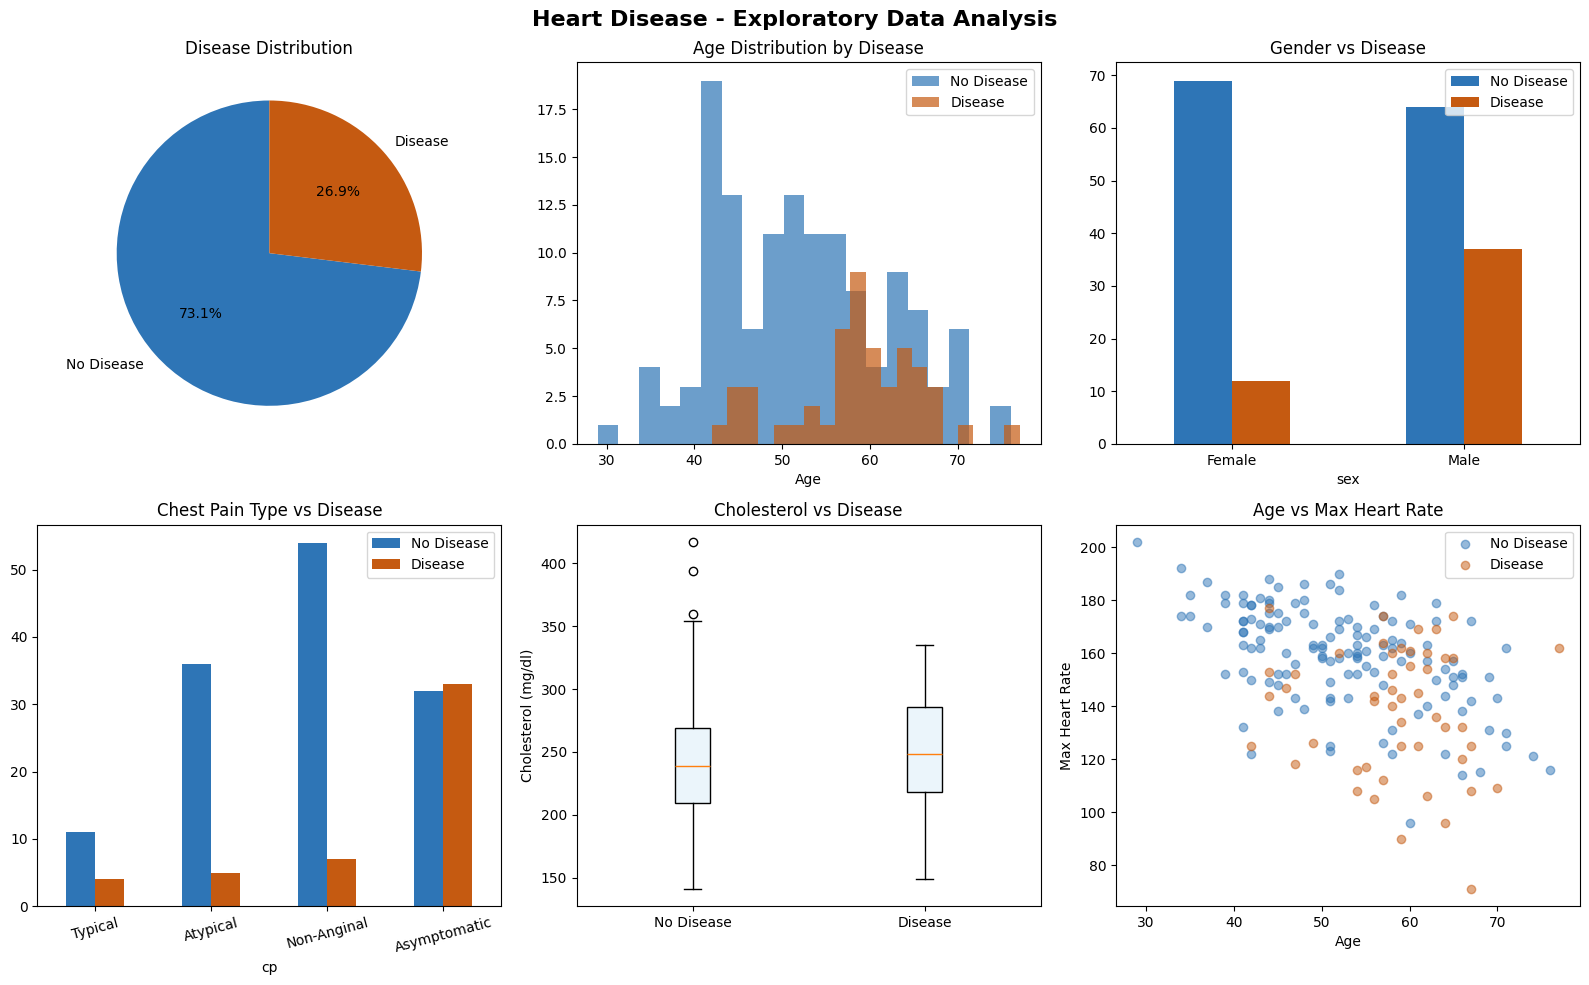

EDA Complete ✅


In [15]:
# =====================================================
# EXPLORATORY DATA ANALYSIS
# =====================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Heart Disease - Exploratory Data Analysis',
             fontsize=16, fontweight='bold')

# 1. Target Distribution
axes[0,0].pie(
    df['target'].value_counts(),
    labels=['No Disease','Disease'],
    colors=['#2E75B6','#C55A11'],
    autopct='%1.1f%%', startangle=90
)
axes[0,0].set_title('Disease Distribution')

# 2. Age Distribution
axes[0,1].hist(df[df['target']==0]['age'],
               alpha=0.7, color='#2E75B6',
               label='No Disease', bins=20)
axes[0,1].hist(df[df['target']==1]['age'],
               alpha=0.7, color='#C55A11',
               label='Disease', bins=20)
axes[0,1].set_title('Age Distribution by Disease')
axes[0,1].set_xlabel('Age')
axes[0,1].legend()

# 3. Gender vs Disease
gender_data = df.groupby(['sex','target']).size().unstack()
gender_data.plot(kind='bar', ax=axes[0,2],
                 color=['#2E75B6','#C55A11'])
axes[0,2].set_title('Gender vs Disease')
axes[0,2].set_xticklabels(['Female','Male'], rotation=0)
axes[0,2].legend(['No Disease','Disease'])

# 4. Chest Pain vs Disease
cp_data = df.groupby(['cp','target']).size().unstack()
cp_data.plot(kind='bar', ax=axes[1,0],
             color=['#2E75B6','#C55A11'])
axes[1,0].set_title('Chest Pain Type vs Disease')
axes[1,0].set_xticklabels(
    ['Typical','Atypical','Non-Anginal','Asymptomatic'],
    rotation=15
)
axes[1,0].legend(['No Disease','Disease'])

# 5. Cholesterol Boxplot
axes[1,1].boxplot(
    [df[df['target']==0]['chol'],
     df[df['target']==1]['chol']],
    labels=['No Disease','Disease'],
    patch_artist=True,
    boxprops=dict(facecolor='#EBF5FB')
)
axes[1,1].set_title('Cholesterol vs Disease')
axes[1,1].set_ylabel('Cholesterol (mg/dl)')

# 6. Age vs Max Heart Rate
axes[1,2].scatter(
    df[df['target']==0]['age'],
    df[df['target']==0]['thalach'],
    alpha=0.5, color='#2E75B6', label='No Disease'
)
axes[1,2].scatter(
    df[df['target']==1]['age'],
    df[df['target']==1]['thalach'],
    alpha=0.5, color='#C55A11', label='Disease'
)
axes[1,2].set_title('Age vs Max Heart Rate')
axes[1,2].set_xlabel('Age')
axes[1,2].set_ylabel('Max Heart Rate')
axes[1,2].legend()

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA Complete ✅")

In [16]:
# =====================================================
# PREPARE DATA
# =====================================================

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")
print("Data Prepared ✅")

Training samples : 145
Testing samples  : 37
Data Prepared ✅


In [17]:
# =====================================================
# UPGRADE 1: 5 MODEL COMPARISON
# =====================================================

models = {
    'Logistic Regression' : LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost'             : XGBClassifier(random_state=42, eval_metric='logloss'),
    'SVM'                 : SVC(probability=True, random_state=42),
    'Neural Network'      : MLPClassifier(hidden_layer_sizes=(100,50),
                                          max_iter=500, random_state=42)
}

results = {}

print("="*55)
print(f"{'Model':<22} {'Accuracy':>10} {'ROC-AUC':>10} {'CV Score':>10}")
print("="*55)

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred      = model.predict(X_test_scaled)
    y_prob      = model.predict_proba(X_test_scaled)[:,1]
    acc         = accuracy_score(y_test, y_pred)
    auc         = roc_auc_score(y_test, y_prob)
    cv          = cross_val_score(model, X_train_scaled,
                                  y_train, cv=5).mean()
    results[name] = {
        'model'   : model,
        'accuracy': acc,
        'roc_auc' : auc,
        'cv_score': cv,
        'y_pred'  : y_pred,
        'y_prob'  : y_prob
    }
    print(f"{name:<22} {acc*100:>9.2f}% {auc:>10.4f} {cv*100:>9.2f}%")

print("="*55)

# Best model select karo
best_name  = max(results, key=lambda x: results[x]['roc_auc'])
best_model = results[best_name]['model']
print(f"\n★ Best Model: {best_name}")
print(f"  Accuracy : {results[best_name]['accuracy']*100:.2f}%")
print(f"  ROC-AUC  : {results[best_name]['roc_auc']:.4f}")

Model                    Accuracy    ROC-AUC   CV Score
Logistic Regression        86.49%     0.7963     84.83%
Random Forest              86.49%     0.7981     81.38%
XGBoost                    83.78%     0.8037     77.24%
SVM                        86.49%     0.7593     82.07%
Neural Network             86.49%     0.8556     79.31%

★ Best Model: Neural Network
  Accuracy : 86.49%
  ROC-AUC  : 0.8556


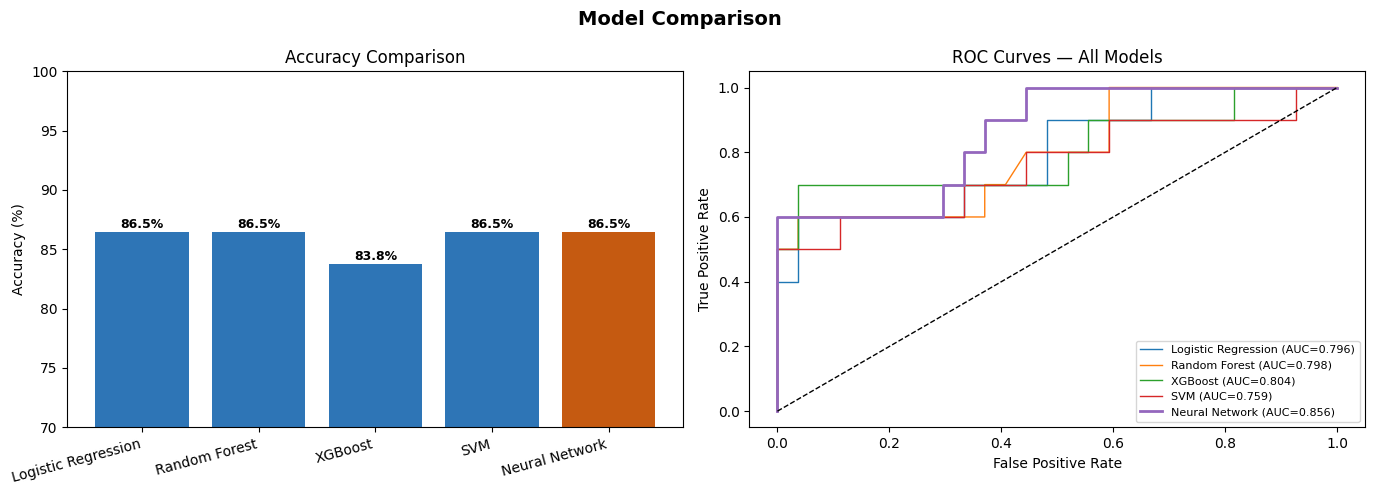

Model Comparison Complete ✅


In [18]:
# =====================================================
# MODEL COMPARISON PLOT
# =====================================================

model_names = list(results.keys())
accuracies  = [results[m]['accuracy']*100 for m in model_names]
aucs        = [results[m]['roc_auc'] for m in model_names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Comparison', fontsize=14, fontweight='bold')

# Accuracy comparison
colors = ['#C55A11' if m == best_name else '#2E75B6'
          for m in model_names]
bars = axes[0].bar(model_names, accuracies, color=colors)
axes[0].set_title('Accuracy Comparison')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(70, 100)
axes[0].set_xticklabels(model_names, rotation=15, ha='right')
for bar, val in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 val + 0.3, f'{val:.1f}%',
                 ha='center', fontsize=9, fontweight='bold')

# ROC Curves
for name in model_names:
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
    axes[1].plot(fpr, tpr,
                 label=f"{name} (AUC={results[name]['roc_auc']:.3f})",
                 linewidth=2 if name == best_name else 1)
axes[1].plot([0,1],[0,1],'k--', linewidth=1)
axes[1].set_title('ROC Curves — All Models')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Model Comparison Complete ✅")

Calculating SHAP values...


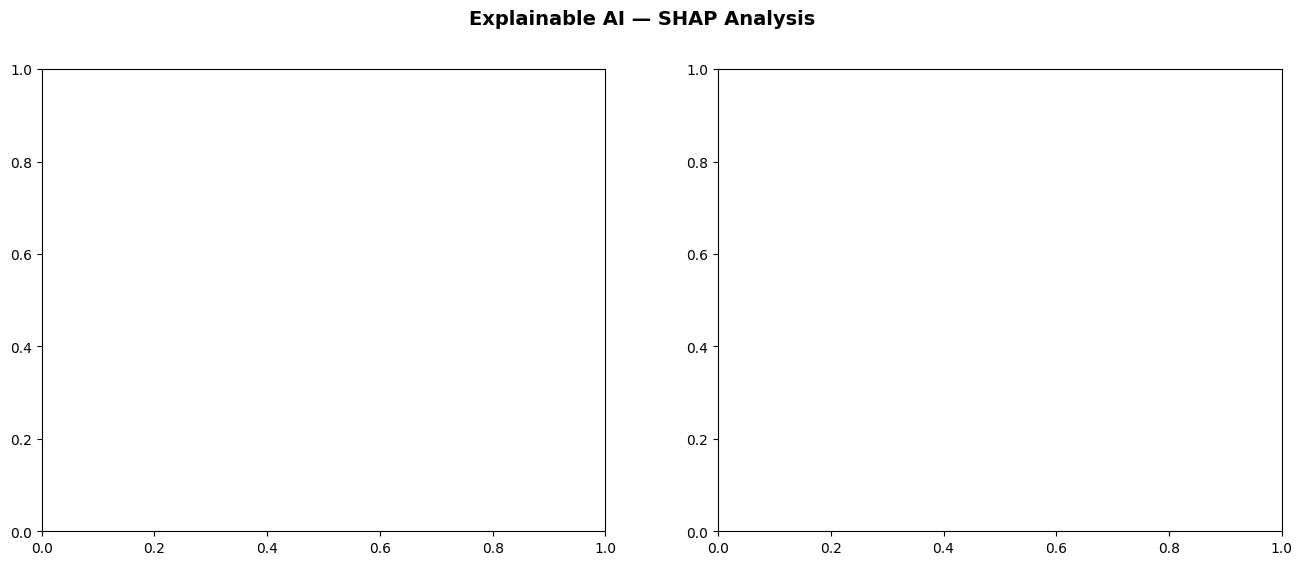

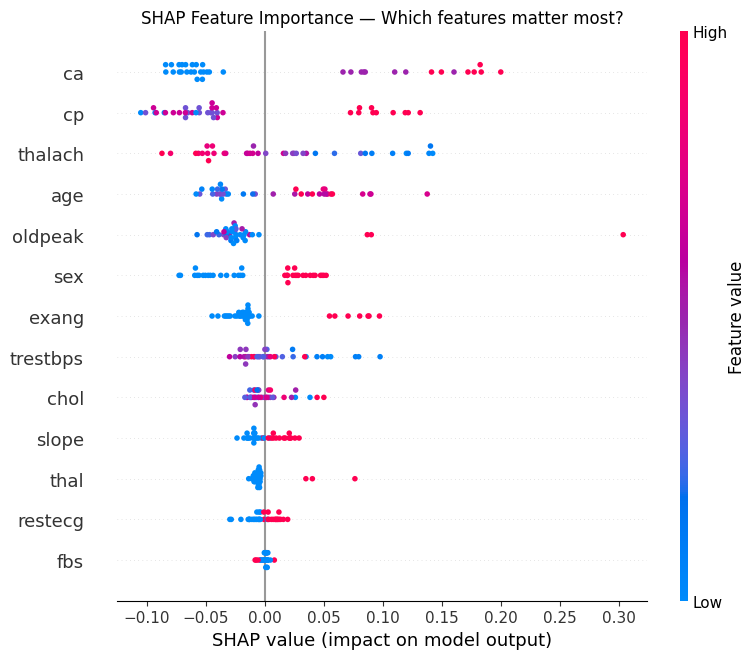

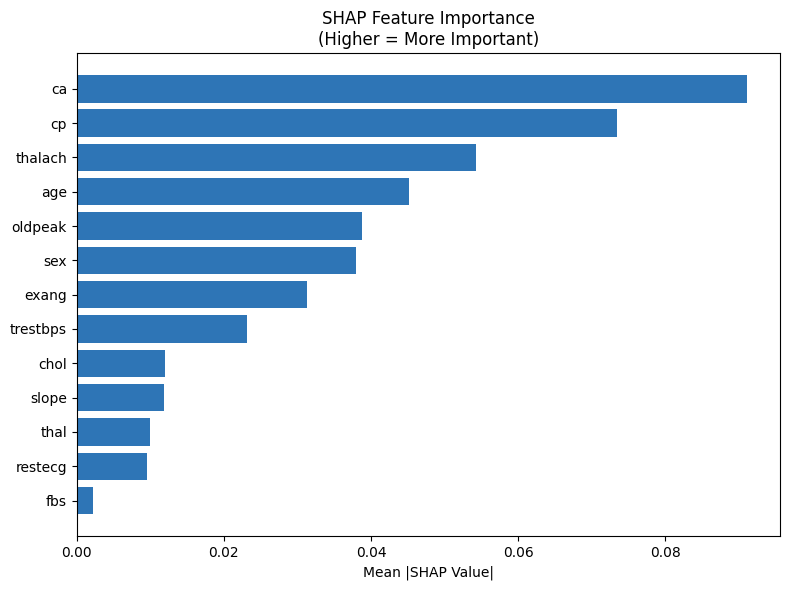

SHAP Analysis Complete ✅

Top 5 Most Important Features:
    Feature  Importance
11       ca    0.091034
2        cp    0.073419
7   thalach    0.054286
0       age    0.045166
9   oldpeak    0.038710


In [19]:
# =====================================================
# UPGRADE 2: EXPLAINABLE AI WITH SHAP
# =====================================================

print("Calculating SHAP values...")

# Random Forest ke liye SHAP
rf_model = results['Random Forest']['model']
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_scaled)

feature_names = X.columns.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Explainable AI — SHAP Analysis',
             fontsize=14, fontweight='bold')

# SHAP Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values[:,:,1] if len(np.array(shap_values).shape) == 3
    else shap_values,
    X_test_scaled,
    feature_names=feature_names,
    show=False
)
plt.title('SHAP Feature Importance — Which features matter most?')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature Importance from SHAP
if len(np.array(shap_values).shape) == 3:
    sv = np.abs(shap_values[:,:,1]).mean(0)
else:
    sv = np.abs(shap_values).mean(0)

feat_imp = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': sv
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(feat_imp['Feature'], feat_imp['Importance'],
         color='#2E75B6')
plt.title('SHAP Feature Importance\n(Higher = More Important)')
plt.xlabel('Mean |SHAP Value|')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("SHAP Analysis Complete ✅")
print("\nTop 5 Most Important Features:")
print(feat_imp.sort_values('Importance', ascending=False).head())

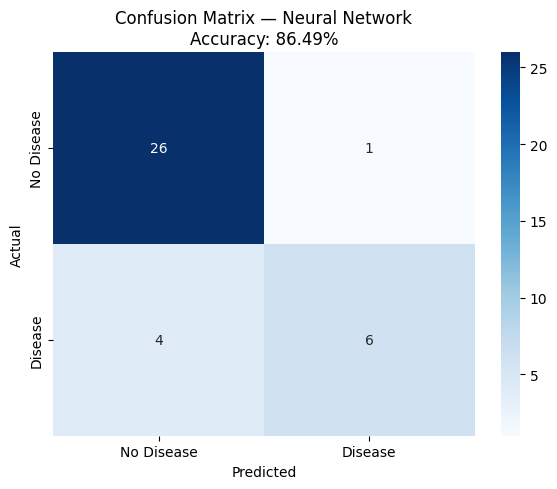


Best Model : Neural Network
Accuracy   : 86.49%
ROC-AUC    : 0.8556

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.87      0.96      0.91        27
     Disease       0.86      0.60      0.71        10

    accuracy                           0.86        37
   macro avg       0.86      0.78      0.81        37
weighted avg       0.86      0.86      0.86        37



In [20]:
# =====================================================
# BEST MODEL EVALUATION
# =====================================================

best_pred = results[best_name]['y_pred']
best_prob = results[best_name]['y_prob']
best_acc  = results[best_name]['accuracy']
best_auc  = results[best_name]['roc_auc']

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease','Disease'],
            yticklabels=['No Disease','Disease'])
plt.title(f'Confusion Matrix — {best_name}\nAccuracy: {best_acc*100:.2f}%')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print(f"\nBest Model : {best_name}")
print(f"Accuracy   : {best_acc*100:.2f}%")
print(f"ROC-AUC    : {best_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, best_pred,
      target_names=['No Disease','Disease']))

In [21]:
# =====================================================
# SAVE BEST MODEL + SCALER + MODEL NAME
# =====================================================

with open('heart_disease_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Model results bhi save karo
summary = {
    name: {
        'accuracy': round(results[name]['accuracy']*100, 2),
        'roc_auc' : round(results[name]['roc_auc'], 4),
        'cv_score': round(results[name]['cv_score']*100, 2)
    }
    for name in results
}

import json
with open('model_results.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("heart_disease_model.pkl saved ✅")
print("scaler.pkl saved ✅")
print("model_results.json saved ✅")
print(f"\nBest Model Saved: {best_name}")
print(f"Final Accuracy  : {best_acc*100:.2f}%")
print(f"Final ROC-AUC   : {best_auc:.4f}")
print("\nDownload these files:")
print("  1. heart_disease_model.pkl")
print("  2. scaler.pkl")
print("  3. model_results.json")
print("  4. Notebook — File → Download")

heart_disease_model.pkl saved ✅
scaler.pkl saved ✅
model_results.json saved ✅

Best Model Saved: Neural Network
Final Accuracy  : 86.49%
Final ROC-AUC   : 0.8556

Download these files:
  1. heart_disease_model.pkl
  2. scaler.pkl
  3. model_results.json
  4. Notebook — File → Download
